# Volatilidad con GARCH: dólar y cartera IPSA

**Pregunta.** ¿Un modelo GARCH con colas pesadas mide mejor el riesgo diario que los métodos del [notebook de riesgo de mercado](../02_finanzas/02_metricas_de_riesgo.ipynb)?

**Datos.** Dólar observado diario desde 2000 y la cartera de pesos iguales de nueve acciones del IPSA desde 2019.

**Método.** Se estiman modelos GARCH(1,1) y GJR-GARCH(1,1) con innovaciones t de Student. Con ellos se pronostica el VaR y el ES al 99% cada día, reestimando los parámetros una vez al mes y usando solo información anterior. Los pronósticos se validan con las mismas pruebas del bloque de finanzas.

**Resultado principal.** El dólar muestra agrupamiento de volatilidad muy persistente. En ambos activos, el GARCH con t de Student pasa las pruebas de Kupiec y Christoffersen, y su ES anticipa la severidad de las pérdidas mucho mejor que los métodos anteriores. Combinar volatilidad dinámica con colas pesadas resuelve las dos fallas que dejó abierto el notebook de riesgo.

## 1. Configuración y datos

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch

from dsaplicado import datos, portafolio as pf, riesgo as rg
from dsaplicado.graficos import COLORES, CRITICO, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo, eje_porcentaje

warnings.filterwarnings("ignore")
aplicar_estilo()
pd.set_option("display.float_format", "{:.4f}".format)

RAIZ = datos.raiz_repositorio()
CARPETA = RAIZ / "03_series_de_tiempo"
NIVEL = 0.99

dolar = datos.cargar_indicador(RAIZ / "datos" / "dolar_historico.csv", "dolar", range(2000, 2027))
retorno_dolar = np.log(dolar).diff().dropna().rename("dolar")

precios = datos.cargar_precios(RAIZ / "datos" / "precios_ipsa.csv", {**datos.ACCIONES_IPSA, **datos.BENCHMARK_IPSA},
                               "2019-01-01", "2026-09-01").ffill()
cartera = pf.retornos_simples(precios[list(datos.ACCIONES_IPSA.values())]).dropna().mean(axis=1).rename("cartera")

print(f"Dólar: {len(retorno_dolar)} retornos diarios, de {retorno_dolar.index[0]:%d-%m-%Y} a {retorno_dolar.index[-1]:%d-%m-%Y}")
print(f"Cartera IPSA: {len(cartera)} retornos diarios, de {cartera.index[0]:%d-%m-%Y} a {cartera.index[-1]:%d-%m-%Y}")

Dólar: 6660 retornos diarios, de 04-01-2000 a 24-09-2026
Cartera IPSA: 1908 retornos diarios, de 03-01-2019 a 31-08-2026


## 2. El dólar y el agrupamiento de volatilidad

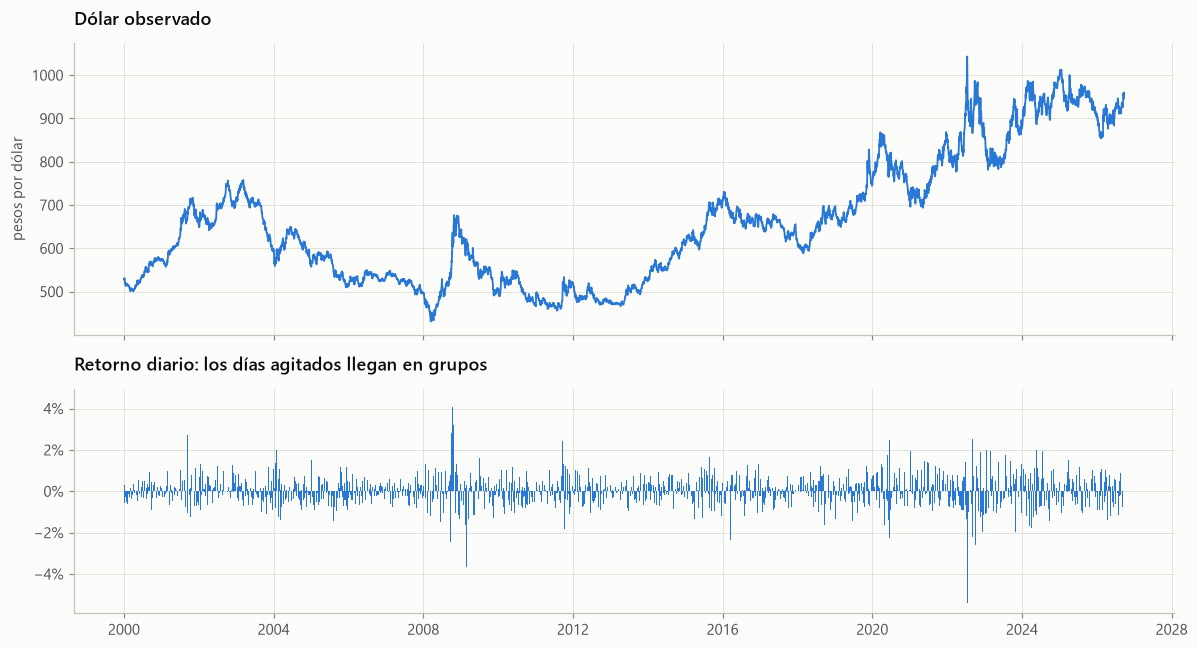

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]})
ax1.plot(dolar.index, dolar, color=COLORES[0], linewidth=1.2)
ax1.set_ylabel("pesos por dólar")
ax1.set_title("Dólar observado")
ax2.bar(retorno_dolar.index, retorno_dolar, width=2, color=COLORES[0])
eje_porcentaje(ax2, decimales=0)
ax2.set_title("Retorno diario: los días agitados llegan en grupos")
fig.tight_layout()
plt.show()

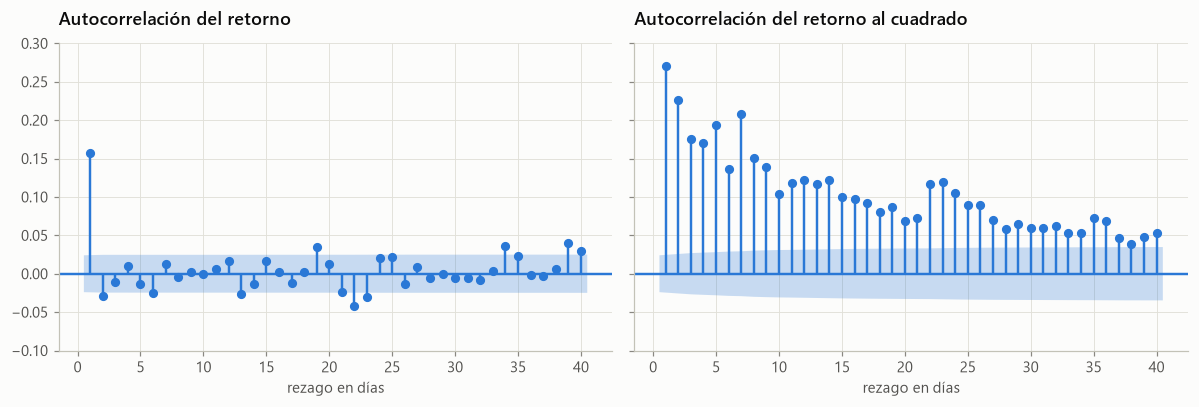

Prueba ARCH-LM con 10 rezagos: estadístico 918, p-valor 9.8e-191


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, serie, titulo in [(ax1, retorno_dolar, "Autocorrelación del retorno"),
                          (ax2, retorno_dolar ** 2, "Autocorrelación del retorno al cuadrado")]:
    plot_acf(serie, lags=40, zero=False, ax=ax, color=COLORES[0], vlines_kwargs={"colors": COLORES[0]})
    ax.set_title(titulo)
    ax.set_ylim(-0.1, 0.3)
    ax.set_xlabel("rezago en días")
fig.tight_layout()
plt.show()

lm = het_arch(retorno_dolar, nlags=10)
print(f"Prueba ARCH-LM con 10 rezagos: estadístico {lm[0]:.0f}, p-valor {lm[1]:.1e}")

El retorno del dólar tiene una autocorrelación positiva solo en el primer rezago. Es un efecto mecánico: el dólar observado es un promedio de las transacciones del día hábil anterior, y promediar precios genera esa dependencia de un día. Desde el segundo rezago no hay autocorrelación relevante, así que la dirección del dólar no se puede predecir. Su cuadrado, en cambio, está fuertemente autocorrelacionado durante semanas. Eso significa que la **magnitud** de los movimientos sí es predecible, aunque su dirección no lo sea. La prueba ARCH-LM lo confirma con holgura. Esa es la estructura que modela un GARCH.

## 3. Estimación con toda la muestra

$$\sigma_t^2 = \omega + (\alpha + \gamma\, \mathbb{1}_{\varepsilon_{t-1}<0})\, \varepsilon_{t-1}^2 + \beta\, \sigma_{t-1}^2$$

En el GARCH simple, $\gamma = 0$. En el GJR-GARCH, $\gamma$ permite que los retornos negativos y positivos afecten la volatilidad de forma distinta.

In [4]:
ajustes = {}
for nombre, o in [("GARCH-t", 0), ("GJR-GARCH-t", 1)]:
    ajustes[nombre] = arch_model(retorno_dolar * 100, mean="Constant", vol="GARCH", p=1, o=o, q=1, dist="t").fit(disp="off")

tabla = {}
for nombre, res in ajustes.items():
    p = res.params
    persistencia = p["alpha[1]"] + p["beta[1]"] + p.get("gamma[1]", 0) / 2
    fila = {f"{k}": v for k, v in p.items()}
    fila.update({f"p-valor {k}": v for k, v in res.pvalues.items() if k in ("alpha[1]", "gamma[1]", "beta[1]")})
    fila.update({"persistencia": persistencia, "vida media, días": np.log(0.5) / np.log(persistencia),
                 "AIC": res.aic, "BIC": res.bic})
    tabla[nombre] = fila
pd.DataFrame(tabla)

,GARCH-t,GJR-GARCH-t
mu,-0.0031,-0.0008
omega,0.0033,0.0036
alpha[1],0.0756,0.0878
beta[1],0.9201,0.9196
nu,9.3337,9.4326
p-valor alpha[1],0.0000,0.0000
p-valor beta[1],0.0000,0.0000
persistencia,0.9956,0.9944
"vida media, días",158.2056,123.0577
AIC,12033.3999,12027.0919


**Lectura.**

- **Volatilidad muy persistente.** La suma de alfa y beta es cercana a uno. Un shock de volatilidad tarda varios meses en disiparse a la mitad.
- **Colas pesadas moderadas.** Los grados de libertad de la t, cerca de nueve, indican colas más pesadas que la normal pero menos extremas que las de las acciones.
- **Asimetría invertida.** En las acciones, las caídas aumentan más la volatilidad que las subidas. En el dólar el coeficiente gamma es negativo y significativo: la volatilidad sube más cuando el dólar sube, es decir, cuando el peso se deprecia. Tiene sentido, porque para Chile el estrés financiero llega con salida de capitales y depreciación del peso.
- **Elección de modelo.** El AIC favorece levemente al GJR, mientras el BIC los considera prácticamente iguales.

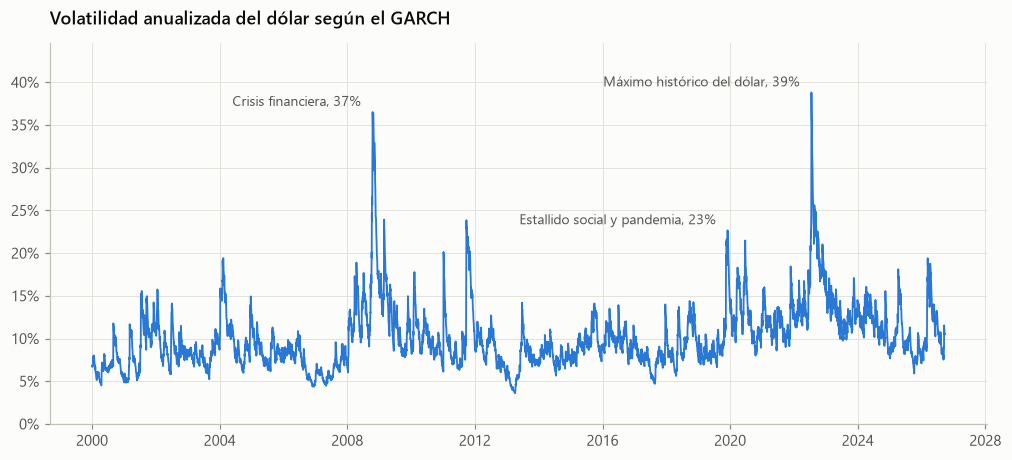

Volatilidad anualizada promedio: 10.1%. Al cierre de la muestra: 10.5%


In [5]:
volatilidad = ajustes["GARCH-t"].conditional_volatility / 100 * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(volatilidad.index, volatilidad, color=COLORES[0], linewidth=1.2)
eventos = [("2008-09-01", "2009-03-31", "Crisis financiera"), ("2019-10-15", "2020-06-30", "Estallido social y pandemia"),
           ("2022-06-01", "2022-09-30", "Máximo histórico del dólar")]
for inicio, fin, texto in eventos:
    tramo = volatilidad.loc[inicio:fin]
    fecha = tramo.idxmax()
    ax.annotate(f"{texto}, {tramo.max():.0%}", (fecha, tramo.max()), xytext=(-8, 4), textcoords="offset points",
                ha="right", fontsize=9, color=TINTA_SECUNDARIA)
eje_porcentaje(ax)
ax.set_ylim(0, volatilidad.max() * 1.15)
ax.set_title("Volatilidad anualizada del dólar según el GARCH")
fig.savefig(CARPETA / "figuras" / "volatilidad_dolar.png", bbox_inches="tight")
plt.show()
print(f"Volatilidad anualizada promedio: {volatilidad.mean():.1%}. Al cierre de la muestra: {volatilidad.iloc[-1]:.1%}")

## 4. Backtesting del VaR del dólar

Ahora cada día se pronostica el VaR al 99% usando solo información anterior. Los GARCH parten con dos años de datos y se reestiman cada mes con ventana creciente. Para comparar, la simulación histórica y el EWMA usan una ventana de 250 días y empiezan el mismo día.

In [6]:
INICIO_DOLAR = 500
pronosticos_dolar = {
    "GARCH-t": rg.pronosticar_var_es_garch(retorno_dolar, NIVEL, INICIO_DOLAR, 21, asimetrico=False),
    "GJR-GARCH-t": rg.pronosticar_var_es_garch(retorno_dolar, NIVEL, INICIO_DOLAR, 21, asimetrico=True),
    "Histórico": rg.pronosticar_var_es(retorno_dolar.iloc[INICIO_DOLAR - 250:], "historico", NIVEL, 250),
    "EWMA": rg.pronosticar_var_es(retorno_dolar.iloc[INICIO_DOLAR - 250:], "ewma", NIVEL, 250),
}

def tabla_backtest(retornos, pronosticos):
    filas = {}
    for nombre, pron in pronosticos.items():
        res = rg.resumen_backtest(retornos, pron, NIVEL)
        filas[nombre] = {
            "excepciones": res["excepciones"], "esperadas": res["esperadas"],
            "p Kupiec": res["p_kupiec"], "p Christoffersen": res["p_christoffersen"],
            "pasa ambas": res["p_kupiec"] > 0.05 and res["p_christoffersen"] > 0.05,
            "VaR promedio": pron["var"].mean(),
            "pérdida real / ES": res["perdida_media_en_exc"] / res["es_medio_en_exc"],
        }
    return pd.DataFrame(filas).T

print(f"Período evaluado: {pronosticos_dolar['GARCH-t'].index[0]:%d-%m-%Y} a {retorno_dolar.index[-1]:%d-%m-%Y}")
tabla_backtest(retorno_dolar, pronosticos_dolar)

Período evaluado: 10-01-2002 a 24-09-2026


,excepciones,esperadas,p Kupiec,p Christoffersen,pasa ambas,VaR promedio,pérdida real / ES
GARCH-t,57,61.6000,0.5508,0.5586,True,0.0161,0.9559
GJR-GARCH-t,60,61.6000,0.8370,0.6179,True,0.0160,0.9520
Histórico,86,61.6000,0.0032,0.0014,False,0.0152,1.1195
EWMA,90,61.6000,0.0007,0.0546,False,0.0148,1.0582


**Lectura.** Los dos GARCH aciertan en la frecuencia y en la independencia de las excepciones. La simulación histórica y el EWMA tienen demasiadas excepciones. La última columna compara la pérdida promedio en los días de excepción con el ES pronosticado: un valor cercano o menor que uno indica que el ES anticipó bien la severidad.

## 5. Backtesting de la cartera IPSA

Se repite el ejercicio con la cartera de acciones del notebook de riesgo, sobre exactamente el mismo período. Allí la t de Student fue el único método que pasó ambas pruebas, pero todos subestimaron la severidad de las pérdidas.

In [7]:
pronosticos_cartera = {
    "GARCH-t": rg.pronosticar_var_es_garch(cartera, NIVEL, 250, 21, asimetrico=False),
    "GJR-GARCH-t": rg.pronosticar_var_es_garch(cartera, NIVEL, 250, 21, asimetrico=True),
    "t de Student": rg.pronosticar_var_es(cartera, "t_student", NIVEL, 250, recalibrar_cada=21),
    "EWMA": rg.pronosticar_var_es(cartera, "ewma", NIVEL, 250),
    "Histórico": rg.pronosticar_var_es(cartera, "historico", NIVEL, 250),
}
print(f"Período evaluado: {pronosticos_cartera['GARCH-t'].index[0]:%d-%m-%Y} a {cartera.index[-1]:%d-%m-%Y}")
resultado_cartera = tabla_backtest(cartera, pronosticos_cartera)
resultado_cartera

Período evaluado: 07-01-2020 a 31-08-2026


,excepciones,esperadas,p Kupiec,p Christoffersen,pasa ambas,VaR promedio,pérdida real / ES
GARCH-t,13,16.5800,0.3584,0.0887,True,0.0361,1.0440
GJR-GARCH-t,14,16.5800,0.5129,0.1055,True,0.0353,1.0590
t de Student,15,16.5800,0.6918,0.1239,True,0.0362,1.1633
EWMA,26,16.5800,0.0318,0.0068,False,0.0312,1.2217
Histórico,21,16.5800,0.2948,0.0269,False,0.0321,1.1773


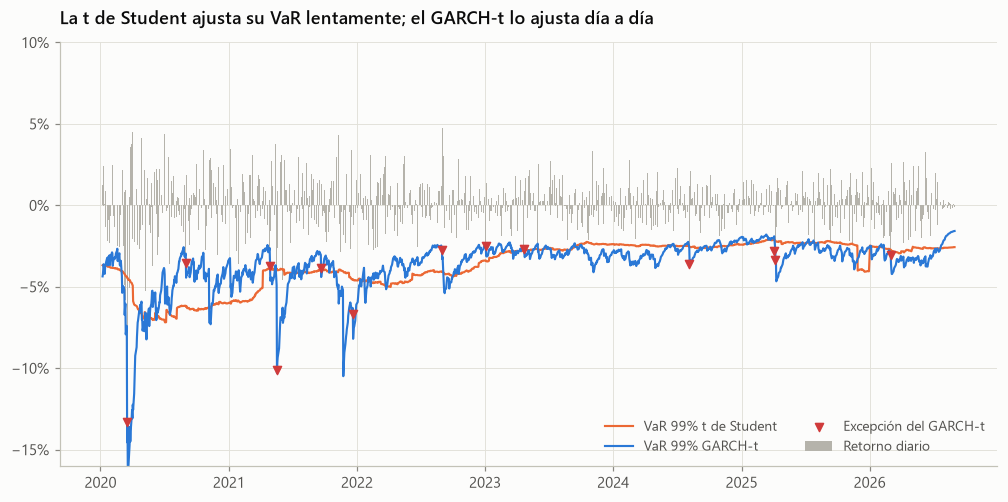

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
inicio = pronosticos_cartera["GARCH-t"].index[0]
r = cartera.loc[inicio:]
ax.bar(r.index, r, width=1.5, color=NEUTRO, label="Retorno diario")
for nombre, color in [("t de Student", COLORES[1]), ("GARCH-t", COLORES[0])]:
    ax.plot(pronosticos_cartera[nombre].index, -pronosticos_cartera[nombre]["var"], color=color, linewidth=1.4,
            label=f"VaR 99% {nombre}")
excepcion = rg.excepciones(cartera, pronosticos_cartera["GARCH-t"]["var"])
dias = excepcion.index[excepcion == 1]
ax.scatter(dias, cartera.loc[dias], s=28, color=CRITICO, marker="v", zorder=4, label="Excepción del GARCH-t")
eje_porcentaje(ax)
ax.set_ylim(-0.16, 0.10)
ax.set_title("La t de Student ajusta su VaR lentamente; el GARCH-t lo ajusta día a día")
ax.legend(loc="lower right", ncols=2, fontsize=9)
fig.savefig(CARPETA / "figuras" / "var_garch_cartera.png", bbox_inches="tight")
plt.show()

**Lectura.** Los GARCH con t de Student también pasan ambas pruebas en la cartera de acciones, con un VaR promedio similar al de la t de Student estática. La diferencia está en la forma: el VaR del GARCH sube de inmediato cuando la volatilidad aumenta y baja cuando el mercado se calma, mientras el de la t de Student cambia recién cuando los días extremos entran o salen de la ventana.

La mejora más importante está en la severidad. En los días de excepción, la pérdida real queda muy cerca del ES pronosticado por los GARCH, mientras los métodos anteriores la subestiman por entre 15% y 25%.

## 6. Conclusiones

1. **La volatilidad del dólar es predecible, aunque su dirección no lo sea.** El agrupamiento de volatilidad es fuerte y persistente, con una vida media de varios meses.
2. **En el peso chileno, la depreciación trae más volatilidad.** Es la asimetría contraria a la de las acciones, coherente con el rol del peso como moneda de riesgo.
3. **GARCH con t de Student es el modelo de VaR más sólido de los evaluados.** Pasa las pruebas de cobertura e independencia en el dólar y en la cartera IPSA, y es el que mejor anticipa la severidad de las pérdidas.
4. **Resuelve la subestimación del ES.** Combinar volatilidad dinámica con colas pesadas corrige la falla que compartían todos los métodos del notebook de riesgo.

## 7. Limitaciones

- **Un activo a la vez.** La cartera se modela como una sola serie. Un modelo multivariado, como un DCC-GARCH, permitiría capturar cómo cambian las correlaciones en las crisis.
- **Horizonte de un día.** Para el horizonte regulatorio de diez días habría que simular trayectorias del GARCH, porque la raíz de diez no es válida cuando la volatilidad cambia en el tiempo.
- **Media constante.** El modelo no incluye la autocorrelación de un día del dólar observado. Su efecto sobre el VaR es pequeño frente al de la volatilidad, pero un término autorregresivo en la media sería más preciso.
- **Recalibración mensual.** Los parámetros se fijan durante un mes. En episodios extremos, reestimar con más frecuencia podría mejorar la reacción.